# 🧪 SentnelOps Internship Assignment  
## AI/ML Reasoning + Anomaly Detection

---

## 📌 Objective

Build a system to detect anomalous or inefficient infrastructure resources using logical reasoning and data-driven validation.

---

## 🧠 Approach

This solution uses a **hybrid approach** combining:

### 🔹 Rule-Based Logic (Primary)
- Detects anomalies using predefined thresholds:
  - Low CPU + High Memory → Over-provisioned
  - High CPU → Under-provisioned
  - High Network → Network-heavy
- Ensures **interpretability and clear reasoning**

### 🔹 Machine Learning (Secondary)
- Uses **Isolation Forest** for anomaly detection
- Identifies statistical outliers in resource metrics
- Acts as a **validation layer**, not the primary decision-maker

---

## ⚙️ Decision Strategy

- Rule-based logic determines the anomaly type
- ML model validates and adjusts confidence

### ✔ Combined Logic:
- Rule + ML agree → Increase confidence  
- ML detects anomaly but rule doesn’t → Mark as suspicious  
- Rule detects anomaly but ML doesn’t → Reduce confidence  

---

## 📊 Features

- Anomaly classification (over/under/network/normal)
- Clear reasoning and actionable suggestions
- Confidence scoring
- ML-based validation
- Security risk detection
- Data visualizations for insights

---

## 📈 Visualizations

The notebook includes:
- Anomaly distribution
- Resource utilization trends
- Normal vs anomalous split
- Rule vs ML agreement

---

## 🧠 Why This Approach

- **Explainable** → Rule-based reasoning is clear  
- **Reliable** → No external API dependency  
- **Practical** → Real-world infrastructure logic  
- **Balanced** → Combines deterministic + data-driven methods  

---

## ⚠️ Limitations

- Fixed thresholds may not generalize  
- No historical/time-series data  
- ML trained on small dataset  

---

## 🔮 Improvements

- Add time-series analysis  
- Dynamic thresholding  
- Advanced ML models  
- Real-time monitoring system  

---

## ✅ Summary

This system demonstrates how combining rule-based logic with machine learning can produce a reliable, interpretable, and practical anomaly detection solution.

In [1]:
!pip install scikit-learn

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

In [3]:
data = [
    {"resource_id": "i-1", "cpu_avg": 2, "cpu_p95": 5, "memory_avg": 70, "network_pct": 10, "internet_facing": True, "identity_attached": True},
    {"resource_id": "i-2", "cpu_avg": 85, "cpu_p95": 98, "memory_avg": 40, "network_pct": 60, "internet_facing": False, "identity_attached": False},
    {"resource_id": "i-3", "cpu_avg": 30, "cpu_p95": 50, "memory_avg": 30, "network_pct": 85, "internet_facing": True, "identity_attached": False},
    {"resource_id": "i-4", "cpu_avg": 50, "cpu_p95": 60, "memory_avg": 50, "network_pct": 20, "internet_facing": False, "identity_attached": False},
    {"resource_id": "i-5", "cpu_avg": 5, "cpu_p95": 10, "memory_avg": 80, "network_pct": 5, "internet_facing": False, "identity_attached": True},
    {"resource_id": "i-6", "cpu_avg": 0, "cpu_p95": 1, "memory_avg": 90, "network_pct": 0, "internet_facing": True, "identity_attached": True},
    {"resource_id": "i-7", "cpu_avg": 95, "cpu_p95": 99, "memory_avg": 95, "network_pct": 95, "internet_facing": True, "identity_attached": False}
]

In [4]:
def analyze_resource(resource):
    cpu_avg = resource["cpu_avg"]
    cpu_p95 = resource["cpu_p95"]
    memory_avg = resource["memory_avg"]
    network_pct = resource["network_pct"]

    is_anomalous = False
    anomaly_type = "normal"
    confidence = 0.5
    security_note = None

    if cpu_avg < 10 and memory_avg > 60:
        is_anomalous = True
        anomaly_type = "over_provisioned"
        confidence += 0.2

    elif cpu_avg > 80 or cpu_p95 > 95:
        is_anomalous = True
        anomaly_type = "under_provisioned"
        confidence += 0.2

    elif network_pct > 80:
        is_anomalous = True
        anomaly_type = "network_heavy"
        confidence += 0.1

    if anomaly_type == "over_provisioned":
        reason = "Low CPU usage with high memory usage indicates inefficient resource allocation."
        action = "Downsize instance to reduce cost."

    elif anomaly_type == "under_provisioned":
        reason = "High CPU usage suggests the system is under heavy load and may degrade performance."
        action = "Scale up resources or optimize workload."

    elif anomaly_type == "network_heavy":
        reason = "High network usage indicates heavy traffic or inefficient data handling."
        action = "Analyze traffic and optimize network usage."

    else:
        reason = "Resource utilization is balanced."
        action = "No action required."


    if resource["internet_facing"] and resource["identity_attached"]:
        security_note = "Public exposure with identity increases attack risk."
        confidence += 0.1

    return {
        "resource_id": resource["resource_id"],
        "is_anomalous": is_anomalous,
        "anomaly_type": anomaly_type,
        "reason": reason,
        "suggested_action": action,
        "confidence": round(min(confidence, 0.95), 2),
        "security_note": security_note
    }

In [5]:

X = np.array([
    [r["cpu_avg"], r["cpu_p95"], r["memory_avg"], r["network_pct"]]
    for r in data
])

iso = IsolationForest(contamination=0.3, random_state=42)
iso.fit(X)

preds = iso.predict(X)
scores = iso.decision_function(X)

In [6]:
results = []

for i, r in enumerate(data):
    res = analyze_resource(r)

    ml_flag = True if preds[i] == -1 else False
    res["ml_anomaly"] = ml_flag
    res["ml_score"] = round(float(scores[i]), 3)

    if res["is_anomalous"] and ml_flag:
        res["confidence"] = min(res["confidence"] + 0.15, 0.95)

    elif not res["is_anomalous"] and ml_flag:
        res["confidence"] = min(res["confidence"] + 0.1, 0.85)

    elif res["is_anomalous"] and not ml_flag:
        res["confidence"] = max(res["confidence"] - 0.1, 0.5)

    results.append(res)

In [7]:
print(json.dumps(results, indent=2))

[
  {
    "resource_id": "i-1",
    "is_anomalous": true,
    "anomaly_type": "over_provisioned",
    "reason": "Low CPU usage with high memory usage indicates inefficient resource allocation.",
    "suggested_action": "Downsize instance to reduce cost.",
    "confidence": 0.7000000000000001,
    "security_note": "Public exposure with identity increases attack risk.",
    "ml_anomaly": false,
    "ml_score": 0.074
  },
  {
    "resource_id": "i-2",
    "is_anomalous": true,
    "anomaly_type": "under_provisioned",
    "reason": "High CPU usage suggests the system is under heavy load and may degrade performance.",
    "suggested_action": "Scale up resources or optimize workload.",
    "confidence": 0.6,
    "security_note": null,
    "ml_anomaly": false,
    "ml_score": 0.004
  },
  {
    "resource_id": "i-3",
    "is_anomalous": true,
    "anomaly_type": "network_heavy",
    "reason": "High network usage indicates heavy traffic or inefficient data handling.",
    "suggested_action": "A

In [8]:
df = pd.DataFrame(results)
df

,resource_id,is_anomalous,anomaly_type,reason,suggested_action,confidence,security_note,ml_anomaly,ml_score
0,i-1,True,over_provisioned,Low CPU usage with high memory usage indicates...,Downsize instance to reduce cost.,0.70,Public exposure with identity increases attack...,False,0.074
1,i-2,True,under_provisioned,High CPU usage suggests the system is under he...,Scale up resources or optimize workload.,0.60,None,False,0.004
2,i-3,True,network_heavy,High network usage indicates heavy traffic or ...,Analyze traffic and optimize network usage.,0.75,None,True,-0.015
3,i-4,False,normal,Resource utilization is balanced.,No action required.,0.50,None,False,0.020
4,i-5,True,over_provisioned,Low CPU usage with high memory usage indicates...,Downsize instance to reduce cost.,0.60,None,False,0.076
5,i-6,True,over_provisioned,Low CPU usage with high memory usage indicates...,Downsize instance to reduce cost.,0.70,Public exposure with identity increases attack...,False,0.034
6,i-7,True,under_provisioned,High CPU usage suggests the system is under he...,Scale up resources or optimize workload.,0.85,None,True,-0.046


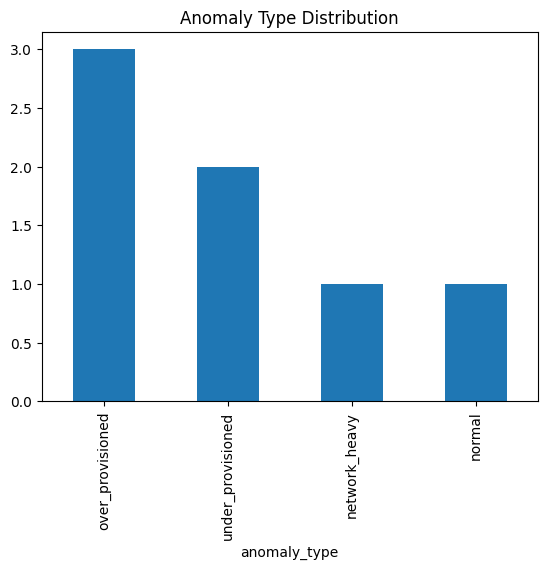

In [9]:
plt.figure()
df["anomaly_type"].value_counts().plot(kind="bar")
plt.title("Anomaly Type Distribution")
plt.show()

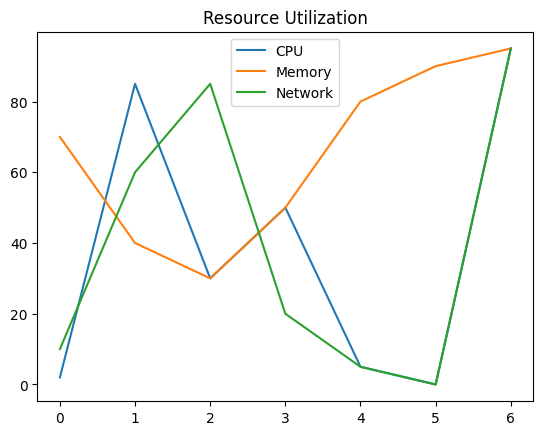

In [10]:
plt.figure()

plt.plot([r["cpu_avg"] for r in data], label="CPU")
plt.plot([r["memory_avg"] for r in data], label="Memory")
plt.plot([r["network_pct"] for r in data], label="Network")

plt.legend()
plt.title("Resource Utilization")
plt.show()

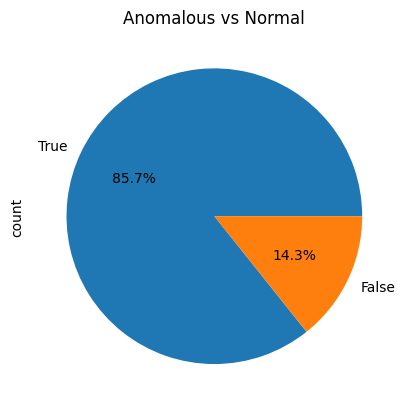

In [11]:
plt.figure()
df["is_anomalous"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Anomalous vs Normal")
plt.show()

<Figure size 640x480 with 0 Axes>

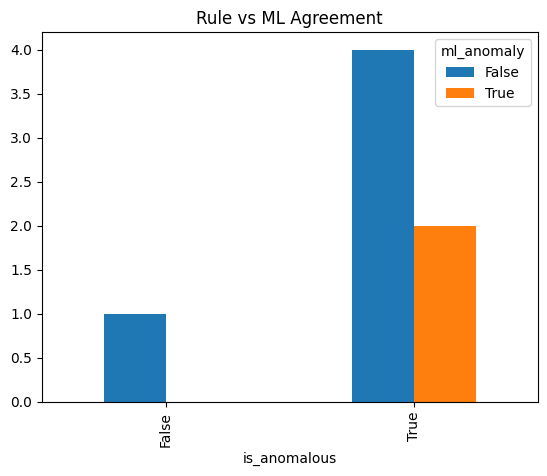

In [12]:
plt.figure()
pd.crosstab(df["is_anomalous"], df["ml_anomaly"]).plot(kind="bar")
plt.title("Rule vs ML Agreement")
plt.show()